In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input, Dense, LSTM, TimeDistributed,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [3]:
!pip install Flask
from flask import Flask

app = Flask(__name__)

@app.route("/")
def home():
    return "Hello Aman! Your project is live 🚀"

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=10000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:10000
 * Running on http://10.100.186.207:10000
Press CTRL+C to quit


In [9]:
!pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 21.8 MB/s eta 0:00:00m eta 0:00:010:01:02
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 21.2 MB/s eta 0:00:001m22.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 15.9 MB/s eta

In [3]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

def load_images(data_dir):
    data = []
    labels = []
    
    classes = ["drowsy", "non_drowsy"]
    
    for label, cls in enumerate(classes):
        path = os.path.join(data_dir, cls)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                
                data.append(img)
                labels.append(label)
            except:
                continue
    
    return np.array(data), np.array(labels)

In [5]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

# Base path
base_path = os.path.expanduser("~/Desktop/dataset")

# Function to create a generator that yields batches as arrays
def image_batch_generator(folder_path, img_size=(128,128), batch_size=32, shuffle=True):
    class_names = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])
    paths_labels = []
    
    # Prepare (image_path, label) tuples
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            paths_labels.append((img_path, label))
    
    if shuffle:
        np.random.shuffle(paths_labels)
    
    n = len(paths_labels)
    for i in range(0, n, batch_size):
        batch = paths_labels[i:i+batch_size]
        X_batch, y_batch = [], []
        for img_path, label in batch:
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            img = img / 255.0
            X_batch.append(img)
            y_batch.append(label)
        if X_batch:  
            X_batch = np.array(X_batch, dtype=np.float32)
            y_batch = to_categorical(np.array(y_batch), num_classes=len(class_names))
            yield X_batch, y_batch

In [7]:
def generator_to_array(generator):
    X_list, y_list = [], []
    for X_batch, y_batch in generator:
        X_list.append(X_batch)
        y_list.append(y_batch)
    X = np.vstack(X_list)
    y = np.vstack(y_list)
    return X, y

X_train, y_train = generator_to_array(image_batch_generator(os.path.join(base_path, "train"), batch_size=256))
X_val, y_val     = generator_to_array(image_batch_generator(os.path.join(base_path, "val"), batch_size=256, shuffle=False))
X_test, y_test   = generator_to_array(image_batch_generator(os.path.join(base_path, "test"), batch_size=256, shuffle=False))

In [9]:
SEQ_LEN = 10

def create_sequences(X, y, seq_len=10):
    sequences = []
    seq_labels = []
    
    for i in range(len(X) - seq_len):
        sequences.append(X[i:i+seq_len])
        seq_labels.append(y[i+seq_len])
    
    return np.array(sequences), np.array(seq_labels)

In [ ]:
X_train, y_train = create_sequences(X_train, y_train, SEQ_LEN)
X_val, y_val = create_sequences(X_val, y_val, SEQ_LEN)
X_test, y_test = create_sequences(X_test, y_test, SEQ_LEN)

In [1]:
import os
import cv2
import numpy as np

IMG_SIZE = 224

def load_images(data_dir):
    data = []
    labels = []
    
    classes = ["drowsy", "non_drowsy"]
    
    for label, cls in enumerate(classes):
        path = os.path.join(data_dir, cls)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                
                data.append(img)
                labels.append(label)
            except:
                continue
    
    return np.array(data), np.array(labels)

In [3]:
base_path = os.path.expanduser("~/Desktop/dataset")
X_train, y_train = load_images(os.path.join(base_path, "train"))
X_val, y_val = load_images(os.path.join(base_path, "val"))
X_test, y_test = load_images(os.path.join(base_path, "test"))

KeyboardInterrupt: 

In [5]:
IMG_SIZE = 96        
SEQ_LEN = 5          
BATCH_SIZE = 4      
EPOCHS = 15

In [7]:
def load_images(data_dir):
    data = []
    labels = []
    
    classes = ["drowsy", "non_drowsy"]
    
    for label, cls in enumerate(classes):
        path = os.path.join(data_dir, cls)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            
            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                
                data.append(img)
                labels.append(label)
            except:
                continue
    
    return np.array(data), np.array(labels)

In [11]:
base_path = os.path.expanduser("~/Desktop/dataset")
X_train, y_train = load_images(os.path.join(base_path, "train"))
X_val, y_val = load_images(os.path.join(base_path, "val"))
X_test, y_test = load_images(os.path.join(base_path, "test"))

KeyboardInterrupt: 

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
IMG_SIZE = 96
BATCH_SIZE = 4

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [11]:
base_path = os.path.expanduser("~/Desktop/dataset")
train_data = train_gen.flow_from_directory(
    os.path.join(base_path, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    os.path.join(base_path, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    os.path.join(base_path, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 50937 images belonging to 2 classes.
Found 16980 images belonging to 2 classes.
Found 16981 images belonging to 2 classes.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3),
    alpha=0.35
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step 


In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 92s 7ms/step - accuracy: 0.9175 - loss: 0.2112 - val_accuracy: 0.9294 - val_loss: 0.1717
Epoch 2/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - accuracy: 0.9375 - loss: 0.1664 - val_accuracy: 0.9295 - val_loss: 0.1688
Epoch 3/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 86s 7ms/step - accuracy: 0.9425 - loss: 0.1546 - val_accuracy: 0.9455 - val_loss: 0.1422
Epoch 4/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 85s 7ms/step - accuracy: 0.9458 - loss: 0.1471 - val_accuracy: 0.9416 - val_loss: 0.1460
Epoch 5/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 84s 7ms/step - accuracy: 0.9461 - loss: 0.1431 - val_accuracy: 0.9485 - val_loss: 0.1408
Epoch 6/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 90s 7ms/step - accuracy: 0.9481 - loss: 0.1392 - val_accuracy: 0.9512 - val_loss: 0.1314
Epoch 7/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 100s 8ms/step - accuracy: 0.9493 - loss: 0.1362 - val_accuracy: 0.9523 - val_loss: 0.1278
Epoch 8/10
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 87s 7ms/step - accuracy

In [17]:
model.evaluate(test_data)

4246/4246 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9553 - loss: 0.1287


[0.1286538541316986, 0.9553030133247375]

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3),
    alpha=0.35
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

In [21]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)   
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

In [27]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
    
)

Epoch 1/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 146s 11ms/step - accuracy: 0.9276 - loss: 0.1831 - val_accuracy: 0.9575 - val_loss: 0.1122 - learning_rate: 1.0000e-04
Epoch 2/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 137s 11ms/step - accuracy: 0.9583 - loss: 0.1153 - val_accuracy: 0.9646 - val_loss: 0.0907 - learning_rate: 1.0000e-04
Epoch 3/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 145s 11ms/step - accuracy: 0.9647 - loss: 0.0971 - val_accuracy: 0.9668 - val_loss: 0.0852 - learning_rate: 1.0000e-04
Epoch 4/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 152s 12ms/step - accuracy: 0.9684 - loss: 0.0874 - val_accuracy: 0.9256 - val_loss: 0.1848 - learning_rate: 1.0000e-04
Epoch 5/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9713 - loss: 0.0790 - val_accuracy: 0.9395 - val_loss: 0.1456 - learning_rate: 1.0000e-04
Epoch 6/15
12735/12735 ━━━━━━━━━━━━━━━━━━━━ 145s 11ms/step - accuracy: 0.9777 - loss: 0.0589 - val_accuracy: 0.9767 - val_loss: 0.0623 - learning_rate: 3.0000e-05
Epoch 7/15
12735/12735

In [29]:
model.evaluate(test_data)

4246/4246 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.9794 - loss: 0.0580


[0.05798492208123207, 0.979447603225708]

In [31]:
from sklearn.metrics import classification_report

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(test_data.classes, y_pred))

4246/4246 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step
              precision    recall  f1-score   support

           0       0.49      0.50      0.50      8390
           1       0.51      0.51      0.51      8591

    accuracy                           0.50     16981
   macro avg       0.50      0.50      0.50     16981
weighted avg       0.50      0.50      0.50     16981



In [33]:
print(train_data.class_indices)

{'drowsy': 0, 'non_drowsy': 1}


In [35]:
classification_report(test_data.classes, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.49      0.50      0.50      8390\n           1       0.51      0.51      0.51      8591\n\n    accuracy                           0.50     16981\n   macro avg       0.50      0.50      0.50     16981\nweighted avg       0.50      0.50      0.50     16981\n'

In [37]:
test_data.reset()

y_pred = model.predict(test_data, verbose=0)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50      8390
           1       0.51      0.51      0.51      8591

    accuracy                           0.50     16981
   macro avg       0.50      0.50      0.50     16981
weighted avg       0.50      0.50      0.50     16981



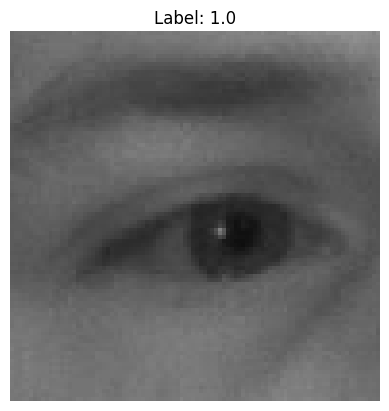

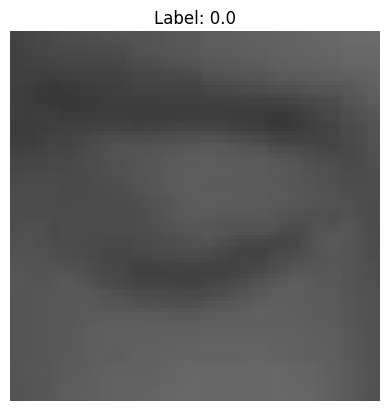

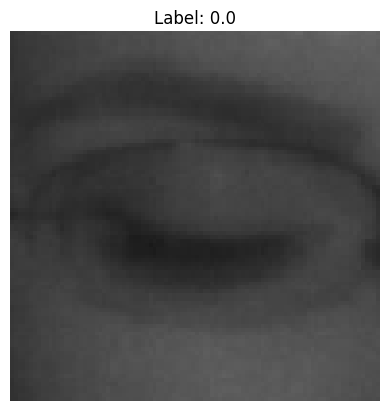

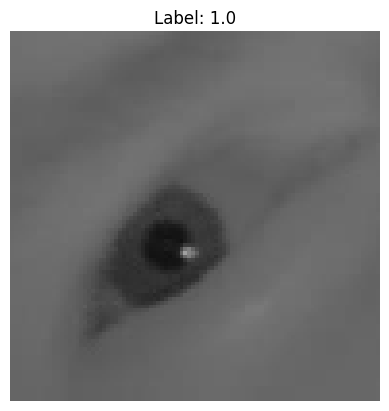

IndexError: index 4 is out of bounds for axis 0 with size 4

In [39]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

for i in range(6):
    plt.imshow(images[i])
    plt.title("Label: " + str(labels[i]))
    plt.axis("off")
    plt.show()

In [41]:
print(train_data.class_indices)

{'drowsy': 0, 'non_drowsy': 1}


In [43]:
for layer in base_model.layers:
    layer.trainable = True   

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [47]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0119799737751818), 1: np.float64(0.9883003492433061)}


In [49]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
 8137/12735 ━━━━━━━━━━━━━━━━━━━━ 2:24 31ms/step - accuracy: 0.9509 - loss: 0.1563

KeyboardInterrupt: 

In [51]:
test_data.reset()

y_pred = model.predict(test_data, verbose=0)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.51      0.50      8390
           1       0.51      0.49      0.50      8591

    accuracy                           0.50     16981
   macro avg       0.50      0.50      0.50     16981
weighted avg       0.50      0.50      0.50     16981



In [57]:
test_data = test_gen.flow_from_directory(
    os.path.join(base_path, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   
)

Found 16981 images belonging to 2 classes.


In [59]:
test_data.reset()

In [61]:
y_pred = model.predict(test_data, verbose=0)
y_pred = (y_pred > 0.5).astype(int).flatten()

y_true = test_data.classes

In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      8390
           1       0.98      0.96      0.97      8591

    accuracy                           0.97     16981
   macro avg       0.97      0.97      0.97     16981
weighted avg       0.97      0.97      0.97     16981



In [65]:
!pip install ultralytics

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.3 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 22.7 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 24.7 MB/s eta 0:00:0031m27.4 MB/s eta 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


In [67]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt") 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/amangarg/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [73]:
def detect_face(frame):
    results = yolo_model(frame)[0]
    
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        conf = box.conf[0]
        cls = int(box.cls[0])
        
        # class 0 = person (we use upper body/face area)
        if cls == 0 and conf > 0.5:
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
            
            h = y2 - y1
            face = frame[y1:y1 + int(h * 0.5), x1:x2]  # upper half = face
            return face
    
    return None

In [75]:
import cv2
import numpy as np

IMG_SIZE = 96

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    face = detect_face(frame)
    
    if face is not None:
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face = face / 255.0
        face = np.expand_dims(face, axis=0)
        
        pred = model.predict(face, verbose=0)[0][0]
        
        label = "DROWSY" if pred > 0.5 else "ALERT"
        
        cv2.putText(frame, label, (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (0, 0, 255), 2)
    
    cv2.imshow("YOLO Drowsiness Detection", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 1 person, 121.8ms
Speed: 33.3ms preprocess, 121.8ms inference, 19.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 62.1ms
Speed: 2.1ms preprocess, 62.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 59.0ms
Speed: 2.0ms preprocess, 59.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 64.4ms
Speed: 2.1ms preprocess, 64.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 55.8ms
Speed: 1.9ms preprocess, 55.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 54.6ms
Speed: 2.1ms preprocess, 54.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 58.3ms
Speed: 1.9ms preprocess, 58.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 58.6ms
Speed: 1.9ms preprocess, 58.6ms inference, 0.7ms postprocess per image at shape (1, 3

KeyboardInterrupt: 

In [99]:
!pip install mediapipe

  Using cached mediapipe-0.10.33-py3-none-macosx_11_0_arm64.whl.metadata (9.8 kB)
Using cached mediapipe-0.10.33-py3-none-macosx_11_0_arm64.whl (29.4 MB)


In [79]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True
)

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [95]:
pip uninstall mediapipe -y

Found existing installation: mediapipe 0.10.33
Uninstalling mediapipe-0.10.33:
  Successfully uninstalled mediapipe-0.10.33
Note: you may need to restart the kernel to use updated packages.


In [97]:
!pip install mediapipe==0.10.9

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33)
ERROR: No matching distribution found for mediapipe==0.10.9


In [101]:
from mediapipe.python.solutions import face_mesh
import cv2
import numpy as np

face_mesh_model = face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True
)

ModuleNotFoundError: No module named 'mediapipe.python'

In [103]:
!pip install mediapipe opencv-python numpy

In [117]:
import cv2
import numpy as np
import mediapipe as mp

from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.face_landmarker import (
    FaceLandmarker,
    FaceLandmarkerOptions
)

import mediapipe as mp
import cv2
import numpy as np

base_options = BaseOptions(
    model_asset_path="face_landmarker.task"
)

options = FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1
)

detector = FaceLandmarker.create_from_options(options)

I0000 00:00:1775674198.619528 4123500 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775674198.622426 4123508 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
import cv2
import numpy as np
import math
import mediapipe as mp
from tensorflow.keras.models import load_model


cnn_model = load_model("light_model.h5")


from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.face_landmarker import (
    FaceLandmarker,
    FaceLandmarkerOptions
)


base_options = BaseOptions(model_asset_path="face_landmarker.task")

options = FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1
)

detector = FaceLandmarker.create_from_options(options)


LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]


def distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))


def compute_ear(eye_points):
    if len(eye_points) != 6:
        return 0

    A = distance(eye_points[1], eye_points[5])
    B = distance(eye_points[2], eye_points[4])
    C = distance(eye_points[0], eye_points[3])

    if C == 0:
        return 0

    return (A + B) / (2.0 * C)


def preprocess(frame):
    img = cv2.resize(frame, (96, 96))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img


drowsy_frames = 0

#  Webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    result = detector.detect(mp_image)

    if result.face_landmarks:
        landmarks = result.face_landmarks[0]

        left_eye_pts = []
        right_eye_pts = []

        for idx in LEFT_EYE:
            lm = landmarks[idx]
            x = int(lm.x * frame.shape[1])
            y = int(lm.y * frame.shape[0])
            left_eye_pts.append((x, y))

        for idx in RIGHT_EYE:
            lm = landmarks[idx]
            x = int(lm.x * frame.shape[1])
            y = int(lm.y * frame.shape[0])
            right_eye_pts.append((x, y))

        # 🔹 EAR
        ear = (compute_ear(left_eye_pts) + compute_ear(right_eye_pts)) / 2.0

        # 🔹 CNN
        cnn_input = preprocess(frame)
        cnn_pred = cnn_model.predict(cnn_input, verbose=0)[0][0]

        # 🔥 HYBRID DECISION
        if ear < 0.25 or cnn_pred > 0.5:
            drowsy_frames += 1
        else:
            drowsy_frames = 0

        if drowsy_frames > 10:
            label = "DROWSY"
            color = (0, 0, 255)
        else:
            label = "ALERT"
            color = (0, 255, 0)

        # 🔹 Display
        cv2.putText(frame, label, (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1,
                    color, 2)

        cv2.putText(frame, f"EAR: {ear:.2f}", (30, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255, 255, 255), 2)

        cv2.putText(frame, f"CNN: {cnn_pred:.2f}", (30, 130),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    (255, 255, 255), 2)

        # 🔹 Draw eyes
        for (x, y) in left_eye_pts + right_eye_pts:
            cv2.circle(frame, (x, y), 2, (0, 0, 255), -1)

    cv2.imshow("Hybrid Drowsiness Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1775723498.603832 4545731 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1775723498.604791 4545733 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [121]:
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

In [131]:
import math

def distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])*2 + (p1[1]-p2[1])*2)

def compute_ear(eye_points):
    A = distance(eye_points[1], eye_points[5])
    B = distance(eye_points[2], eye_points[4])
    C = distance(eye_points[0], eye_points[3])

    return (A + B) / (2.0 * C)

In [2]:
from tensorflow.keras.models import load_model

cnn_model = load_model("light_model.h5")

In [141]:
model.save("light_model.h5")

In [145]:
def preprocess_eye(frame):
    img = cv2.resize(frame, (96, 96))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img